<a href="https://colab.research.google.com/github/Luckaz7/teste_spark_Lucas_Carvalho/blob/main/teste_spark_Lucas_Carvalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# `Instruções para o teste`

## ⚠️ Importante

Antes de iniciar, não esqueça de renomear esse documento substituindo o texto **SEU_NOME** no título com o nome de quem for resolver.

Deixe as respostas bem sinalizadas e comentadas e mencionando a qual questão se refere.

Fique à vontade para utilizar quantas células forem necessárias.

<br><br>

## 📖 Recursos Permitidos
✅ Documentação, sites, fóruns  
❌ Inteligências Artificiais (ChatGPT, Claude, etc.)

<br><br>

## 📤 Instruções para Entrega

**Ao finalizar o teste** volte a este passo e execute a célula abaixo.

**Envie o arquivo gerado e o arquivo do seu notebook para o e-mail:** `mateus.camacho@tdwbi.com.br`

- Arquivo gerado: `historico_exec.txt` <br>
- Seu notebook: `teste_spark_SEU_NOME.ipynb`


In [ ]:
with open('/content/historico_exec.txt', 'w') as f:
    for i, cmd in enumerate(In):
        if cmd.strip():
            f.write(f"\n\nIn[{i}]:\n{cmd}\n\n")

# Baixar arquivo
from google.colab import files
files.download('/content/historico_exec.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# `Questões e Contexto`

## 📁 Contexto

No diretório raiz desse documento, existem os três arquivos que serão necessários para a conclusão dessa atividade. Em caso de dúvidas, a pasta de se encontra no desktop dessa máquina na pasta 'pyspark_test'.

Os dados são fictícios e compreendem uma simulação de um cenário de uma loja de departamentos, para isso temos os arquivos com as seguintes informações:
- **users.csv** → Dados dos clientes/usuários da loja
- **sales.csv** → Dados das vendas
- **products.json** → Dados de cadastro dos produtos

<br><br>

## 📝 Questões

A atividade consiste nas questões a seguir:

**1.** Declare um novo dataframe que mostre o nome do produto e o valor final da compra.

**2.** Declare um novo dataframe com o valor total gasto por cliente.

**3.** Declare um novo dataframe com os cinco melhores clientes contendo o nome, e-mail e o valor gasto em todo o período.

**4.** Declare um novo dataframe com os cinco produtos mais vendidos nos últimos seis meses (considerando período de dados disponível nos arquivos) contendo o nome do produto e a quantidade de produtos vendidos nesse período.

**5.** Calcular a média de faturamento por cliente e o desvio padrão.

**6.** Classificar os clientes em três categorias: silver, gold, platinum
- **platinum:** clientes que gastaram mais que a média de faturamento por cliente;
- **gold:** clientes que gastaram do menor desvio padrão até a média de faturamento por cliente;
- **silver:** clientes que gastaram no máximo a média menos o desvio padrão do faturamento por cliente;

**7.** Salvar um arquivo parquet com os três produtos mais consumidos de cada categoria do cliente.

---

# `Configuração do ambiente`

**Execute as células abaixo antes de iniciar o teste.**

Os arquivos serão criados automaticamente e estarão disponíveis no ícone de pasta do menu lateral (conforme imagem abaixo) ou na pasta **content**.

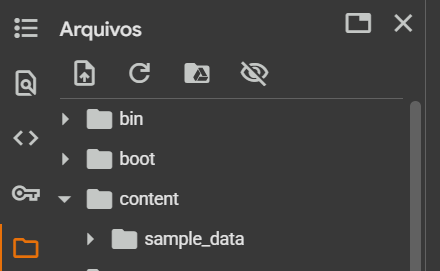


In [ ]:
### IMPORTANDO ARQUIVOS QUE SERÃO USADOS NO TESTE ###

!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/products.json -O products.json
!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/sales.csv -O sales.csv
!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/users.csv -O users.csv

path_products = "/content/products.json"
path_sales = "/content/sales.csv"
path_users = "/content/users.csv"

In [2]:
### IMPORTANDO BIBLIOTECAS NECESSÁRIAS ###

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [3]:
### INSTANCIANDO SPARK ###

spark = SparkSession.builder.appName('test-spark').getOrCreate()

---

# Seu teste começa aqui 🍀 Boa sorte!

## Ingestão dos dados

In [14]:
df_products = spark.read.json(path_products)
df_sales = spark.read.csv(path_sales, header=True, inferSchema=True)
df_users = spark.read.csv(path_users, header=True, inferSchema=True)

## Modelagem dos dados

DataFrame Products:

In [15]:
df_products.printSchema()

root
 |-- price: string (nullable = true)
 |-- product: string (nullable = true)
 |-- product_id: long (nullable = true)



In [20]:
df_products_limpo = df_products.withColumn('price', regexp_replace(df_products['price'], '\\$', '').cast('double'))
colunas_tipadas_products = [
    col('price'),
    col('product'),
    col('product_id').cast('int')
]

df_products_limpo = df_products_limpo.select(*colunas_tipadas_products)

In [21]:
df_products_limpo.printSchema()

root
 |-- price: double (nullable = true)
 |-- product: string (nullable = true)
 |-- product_id: integer (nullable = true)



DataFrame Sales:

In [16]:
df_sales.printSchema()

root
 |-- sale_id: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- client_id: integer (nullable = true)
 |-- qtde: integer (nullable = true)



In [30]:
df_sales_limpo = df_sales.withColumn('date', to_date(df_sales['date'], 'dd/MM/yyyy'))

In [32]:
df_sales_limpo.printSchema()

root
 |-- sale_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- client_id: integer (nullable = true)
 |-- qtde: integer (nullable = true)



DataFrame users:

In [25]:
df_users.printSchema() # Tipagem Ok

root
 |-- client_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- login: string (nullable = true)
 |-- password: string (nullable = true)



## Resposta Questão 1: **Declare um novo dataframe que mostre o nome do produto e o valor final da compra**

In [35]:
df_vendas_produtos = df_sales_limpo.join(df_products_limpo, 'product_id')
df_vendas_produtos = df_vendas_produtos.withColumn('valor_final', df_vendas_produtos['qtde'] * df_vendas_produtos['price'])

In [36]:
df_vendas_produtos.select('product', 'valor_final').show()

+------------------+-----------+
|           product|valor_final|
+------------------+-----------+
|     Blusa Cropped|      214.5|
|Camiseta Estampada|     218.38|
|     Óculos de Sol|     244.54|
|        Bolsa Tote|     105.96|
|     Camisa Social|     161.52|
|Conjunto de Pijama|      85.49|
|     Camiseta Polo|     224.04|
|        Macaquinho|     191.32|
|     Chapéu Fedora|     301.77|
|    Blusa de Renda|       98.9|
|     Camisa Xadrez|      102.7|
|         Sapatênis|     251.76|
|        Sapatilhas|     123.33|
|       Camisa Polo|      259.5|
| Casaco de Inverno|     235.76|
|Suéter de Cashmere|      82.64|
|Calça Cintura Alta|      218.6|
|     Camiseta Polo|     336.06|
|     Jaqueta Jeans|     116.02|
|  Vestido Camisola|       95.6|
+------------------+-----------+
only showing top 20 rows


## Resposta Questão 2: **Declare um novo dataframe com o valor total gasto por cliente.**

In [43]:
df_total_gasto_cliente = df_vendas_produtos.groupBy('client_id').agg(sum('valor_final').alias('tot_gasto_cliente'))

In [44]:
df_total_gasto_cliente.show()

+---------+------------------+
|client_id| tot_gasto_cliente|
+---------+------------------+
|      148|            307.88|
|      243|            280.28|
|       31|            1755.6|
|      137| 624.8199999999999|
|      251|            837.55|
|       85|            688.92|
|       65|            124.43|
|       53|1751.6699999999998|
|      255| 791.3599999999999|
|      133|           1107.99|
|      296| 787.0799999999999|
|       78|           1260.94|
|      155|            974.77|
|      108|            538.87|
|      211|            708.44|
|       34|             851.9|
|      193|            374.04|
|      126| 884.0600000000001|
|      101|1176.8899999999999|
|      115|            201.18|
+---------+------------------+
only showing top 20 rows


## Resposta Questão 3: **Declare um novo dataframe com os cinco melhores clientes contendo o nome, e-mail e o valor gasto em todo o período.**

In [69]:
df_ranking_clientes = (
    df_total_gasto_cliente
    .join(df_users, 'client_id')
    .orderBy(desc('tot_gasto_cliente'))
    .select('name', 'email', 'tot_gasto_cliente')
    .limit(5)
)

In [70]:
df_ranking_clientes.show()

+-----------------+--------------------+------------------+
|             name|               email| tot_gasto_cliente|
+-----------------+--------------------+------------------+
|Randa Friedenbach|rfriedenbach3m@pa...|           2240.51|
|  Giuditta Blease|gblease6s@friendf...|           1902.85|
|     Cher Higford| chigfordn@issuu.com|           1843.35|
|    Keen Juggings|kjuggings5j@phoca.cz|1795.8600000000001|
|    Alfie Pattlel|apattlelu@discuz.net|            1755.6|
+-----------------+--------------------+------------------+



## Resposta Questão 4: **Declare um novo dataframe com os cinco produtos mais vendidos nos últimos seis meses (considerando período de dados disponível nos arquivos) contendo o nome do produto e a quantidade de produtos vendidos nesse período.**

In [52]:
data_maxima = df_vendas_produtos.select(max('date')).collect()[0][0]
data_maxima

datetime.date(2022, 12, 30)

In [54]:
data_corte = df_vendas_produtos.select(add_months(lit(data_maxima), -6)).collect()[0][0]
data_corte

datetime.date(2022, 6, 30)

In [58]:
df_ranking_produtos = (
    df_vendas_produtos
    .filter(col('date') >= data_corte)
    .groupBy('product')
    .agg(sum('qtde')
    .alias('total_vendido'))
    .orderBy(desc('total_vendido'))
    .limit(5)
)

In [59]:
df_ranking_produtos.show()

+--------------------+-------------+
|             product|total_vendido|
+--------------------+-------------+
|          Macaquinho|           39|
|Blusa de Manga Longa|           34|
|      Blusa de Malha|           29|
|   Casaco de Inverno|           29|
|      Bolsa de Couro|           27|
+--------------------+-------------+



##**Resposta Questão 5:** *Calcular a média de faturamento por cliente e o desvio padrão.*

In [103]:
df_stats_consolidado = df_total_gasto_cliente.select(
    avg('tot_gasto_cliente').alias('media'),
    stddev('tot_gasto_cliente').alias('desvio')
)

media_gasto = df_stats_consolidado.select('media').first()[0]
desvio_gasto = df_stats_consolidado.select('desvio').first()[0]

In [89]:
df_stats_consolidado.show()

+-----------------+-----------------+
|            media|           desvio|
+-----------------+-----------------+
|707.2573539518903|414.3416116528876|
+-----------------+-----------------+



In [104]:
media_gasto

707.2573539518903

In [105]:
desvio_gasto

414.3416116528876

## **Resposta Questão 6:** *Classificar os clientes em três categorias: silver, gold, platinum*

    platinum: clientes que gastaram mais que a média de faturamento por cliente;
    gold: clientes que gastaram do menor desvio padrão até a média de faturamento por cliente;
    silver: clientes que gastaram no máximo a média menos o desvio padrão do faturamento por cliente;


In [76]:
df_classificado = (
    df_total_gasto_cliente.withColumn('classe', when(col('tot_gasto_cliente') > media_gasto, 'platinum')
    .when(col('tot_gasto_cliente') >= (media_gasto - desvio_gasto), 'gold')
    .otherwise('silver'))
)

In [77]:
df_classificado.show()

+---------+------------------+--------+
|client_id| tot_gasto_cliente|  classe|
+---------+------------------+--------+
|      148|            307.88|    gold|
|      243|            280.28|  silver|
|       31|            1755.6|platinum|
|      137| 624.8199999999999|    gold|
|      251|            837.55|platinum|
|       85|            688.92|    gold|
|       65|            124.43|  silver|
|       53|1751.6699999999998|platinum|
|      255| 791.3599999999999|platinum|
|      133|           1107.99|platinum|
|      296| 787.0799999999999|platinum|
|       78|           1260.94|platinum|
|      155|            974.77|platinum|
|      108|            538.87|    gold|
|      211|            708.44|platinum|
|       34|             851.9|platinum|
|      193|            374.04|    gold|
|      126| 884.0600000000001|platinum|
|      101|1176.8899999999999|platinum|
|      115|            201.18|  silver|
+---------+------------------+--------+
only showing top 20 rows


## **Resposta Questão 7:** *Salvar um arquivo parquet com os três produtos mais consumidos de cada categoria do cliente.*

In [109]:
df_vendas_classe = (
    df_vendas_produtos
    .join(df_classificado, 'client_id')
    .groupBy('classe', 'product')
    .agg(sum('qtde').alias('total_vendas'))
    .orderBy(col('classe'), col('total_vendas').desc())
)

In [110]:
df_vendas_classe.show()

+------+--------------------+------------+
|classe|             product|total_vendas|
+------+--------------------+------------+
|  gold|   Casaco de Inverno|          26|
|  gold|      Cinto de Couro|          26|
|  gold|       Camisa Xadrez|          23|
|  gold|       Calça Legging|          21|
|  gold|     Tênis Esportivo|          19|
|  gold|        Vestido Midi|          17|
|  gold|      Bolsa de Couro|          16|
|  gold|          Macaquinho|          15|
|  gold|      Blusa de Malha|          15|
|  gold|    Jaqueta de Couro|          15|
|  gold|  Suéter de Cashmere|          14|
|  gold|    Vestido de Festa|          13|
|  gold|       Saia Plissada|          12|
|  gold|    Camisola de Seda|          12|
|  gold|           Sapatênis|          11|
|  gold|    Vestido de Verão|          11|
|  gold|      Blusa de Alças|          11|
|  gold|Blusa de Manga Longa|          11|
|  gold|         Calça Flare|          11|
|  gold|       Jaqueta Jeans|          11|
+------+---

In [111]:
df_top_platinum = df_vendas_classe.filter(col('classe') == 'platinum').limit(3)
df_top_gold = df_vendas_classe.filter(col('classe') == 'gold').limit(3)
df_top_silver = df_vendas_classe.filter(col('classe') == 'silver').limit(3)

In [112]:
df_mais_consumidos_por_categoria = df_top_platinum.union(df_top_gold).union(df_top_silver)

In [114]:
df_mais_consumidos_por_categoria.show(truncate=False)

+--------+---------------------+------------+
|classe  |product              |total_vendas|
+--------+---------------------+------------+
|platinum|Blusa de Manga Longa |57          |
|platinum|Mochila de Lona      |52          |
|platinum|Calça Cintura Alta   |45          |
|gold    |Casaco de Inverno    |26          |
|gold    |Cinto de Couro       |26          |
|gold    |Camisa Xadrez        |23          |
|silver  |Macaquinho           |7           |
|silver  |Sapatos de Salto Alto|6           |
|silver  |Conjunto de Pijama   |5           |
+--------+---------------------+------------+



In [113]:
df_mais_consumidos_por_categoria.write.mode('overwrite').parquet('produtos_mais_consumidos_por_categoria.parquet')